Training on GPU will be fine for transfer learning as it is not a very demanding process.

## Imports

In [3]:
import os, sys, math
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
print("Tensorflow version " + tf.__version__)
AUTOTUNE = tf.data.AUTOTUNE

Tensorflow version 2.20.0


In [4]:
# Fix for Protobuf version incompatibility, importlib_resources, and tensorflow_datasets
!pip install --upgrade tensorflow-datasets protobuf importlib_resources

## Configuration

In [5]:
# GCS_PATTERN = 'gs://flowers-tfrecords/flowers.tfrecord-*' # No longer needed, using tensorflow_datasets
IMAGE_SIZE = [192, 192]

BATCH_SIZE = 64 # 128 works on GPU too but comes very close to the memory limit of the Colab GPU
EPOCHS = 5

VALIDATION_SPLIT = 0.19 # This value is used for context, actual split is handled by tfds.load
# CLASSES = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips'] # This will be populated by tfds metadata

# The following lines were for GCS pattern loading and will be replaced by tensorflow_datasets
# filenames = tf.io.gfile.glob(GCS_PATTERN)
# split = int(len(filenames) * VALIDATION_SPLIT)
# training_filenames = filenames[split:]
# validation_filenames = filenames[:split]
# print("Pattern matches {} data files. Splitting dataset into {} training files and {} validation files".format(len(filenames), len(training_filenames), len(validation_filenames)))
# validation_steps = int(3670 // len(filenames) * len(validation_filenames)) // BATCH_SIZE
# steps_per_epoch = int(3670 // len(filenames) * len(training_filenames)) // BATCH_SIZE
# print("With a batch size of {}, there will be {} batches per training epoch and {} batch(es) per validation run.".format(BATCH_SIZE, steps_per_epoch, validation_steps))

# Note: Global variables like CLASSES, training_dataset, validation_dataset,
# steps_per_epoch, and validation_steps will be defined in the following
# tensorflow_datasets loading cells.

In [6]:
import tensorflow_datasets as tfds

# Load the tf_flowers dataset
(raw_training_dataset, raw_validation_dataset), metadata = tfds.load(
    'tf_flowers',
    split=['train[{}%:]'.format(int(VALIDATION_SPLIT * 100)), 'train[:{}%]'.format(int(VALIDATION_SPLIT * 100))],
    with_info=True,
    as_supervised=True # Download data as (image, label) tuples
)

# Get class names and number of classes from metadata
CLASSES = metadata.features['label'].names
num_classes = metadata.features['label'].num_classes
print(f"Detected {num_classes} classes: {CLASSES}")

# Count the number of examples in each split
num_train_examples = metadata.splits['train'].num_examples - int(metadata.splits['train'].num_examples * VALIDATION_SPLIT)
num_validation_examples = int(metadata.splits['train'].num_examples * VALIDATION_SPLIT)

print(f"Number of training examples: {num_train_examples}")
print(f"Number of validation examples: {num_validation_examples}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.2X5S4O_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Detected 5 classes: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
Number of training examples: 2973
Number of validation examples: 697


In [7]:
def preprocess_image(image, label):
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0 # Normalize to [0,1]
    return image, label

# Apply preprocessing to datasets
training_dataset = raw_training_dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)
validation_dataset = raw_validation_dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)

# Configure datasets for performance
training_dataset = training_dataset.cache().shuffle(buffer_size=1000).repeat().batch(BATCH_SIZE).prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Calculate steps per epoch
steps_per_epoch = int(math.ceil(num_train_examples / BATCH_SIZE))
validation_steps = int(math.ceil(num_validation_examples / BATCH_SIZE))

print(f"With a batch size of {BATCH_SIZE}, there will be {steps_per_epoch} batches per training epoch and {validation_steps} batch(es) per validation run.")

With a batch size of 64, there will be 47 batches per training epoch and 11 batch(es) per validation run.


In [8]:
#@title display utilities [RUN ME]

def dataset_to_numpy_util(dataset, N):
  dataset = dataset.batch(N)

  for images, labels in dataset:
    numpy_images = images.numpy()
    numpy_labels = labels.numpy()
    break;

  return numpy_images, numpy_labels

def title_from_label_and_target(label, correct_label):
  correct = (label == correct_label)
  return "{} [{}{}{}]".format(CLASSES[label], str(correct), ', shoud be ' if not correct else '',
                              CLASSES[correct_label] if not correct else ''), correct

def display_one_flower(image, title, subplot, red=False):
    plt.subplot(subplot)
    plt.axis('off')
    plt.imshow(image)
    plt.title(title, fontsize=16, color='red' if red else 'black')
    return subplot+1

def display_9_images_from_dataset(dataset):
  subplot=331
  plt.figure(figsize=(13,13))
  images, labels = dataset_to_numpy_util(dataset, 9)
  for i, image in enumerate(images):
    title = CLASSES[labels[i]]
    subplot = display_one_flower(image, title, subplot)
    if i >= 8:
      break;

  #plt.tight_layout()
  plt.subplots_adjust(wspace=0.1, hspace=0.1)
  plt.show()

def display_9_images_with_predictions(images, predictions, labels):
  subplot=331
  plt.figure(figsize=(13,13))
  classes = np.argmax(predictions, axis=-1)
  for i, image in enumerate(images):
    title, correct = title_from_label_and_target(classes[i], labels[i])
    subplot = display_one_flower(image, title, subplot, not correct)
    if i >= 8:
      break;

  #plt.tight_layout()
  plt.subplots_adjust(wspace=0.1, hspace=0.1)
  plt.show()

def display_training_curves(training, validation, title, subplot):
  if subplot%10==1: # set up the subplots on the first call
    plt.subplots(figsize=(10,10), facecolor='#F0F0F0')
    #plt.tight_layout()
  ax = plt.subplot(subplot)
  ax.set_facecolor('#F8F8F8')
  ax.plot(training)
  ax.plot(validation)
  ax.set_title('model '+ title)
  ax.set_ylabel(title)
  ax.set_xlabel('epoch')
  ax.legend(['train', 'valid.'])

## Read images and labels from TFRecords

In [10]:
def read_tfrecord(example):
    features = {
        "image": tf.io.FixedLenFeature([], tf.string), # tf.string means bytestring
        "class": tf.io.FixedLenFeature([], tf.int64),  # shape [] means scalar
    }
    example = tf.io.parse_single_example(example, features)
    image = tf.io.decode_jpeg(example['image'], channels=3)
    image = tf.cast(image, tf.float32) / 255.0  # convert image to floats in [0, 1] range
    image = tf.reshape(image, [*IMAGE_SIZE, 3]) # explicit size will be needed for TPU
    class_label = example['class']
    return image, class_label

def load_dataset(filenames):
  # read from TFRecords. For optimal performance, read from multiple
  # TFRecord files at once and set the option experimental_deterministic = False
  # to allow order-altering optimizations.

  option_no_order = tf.data.Options()
  option_no_order.experimental_deterministic = False

  dataset = tf.data.TFRecordDataset(filenames, num_parallel_reads=AUTOTUNE)
  dataset = dataset.with_options(option_no_order)
  dataset = dataset.map(read_tfrecord, num_parallel_calls=AUTOTUNE)
  return dataset

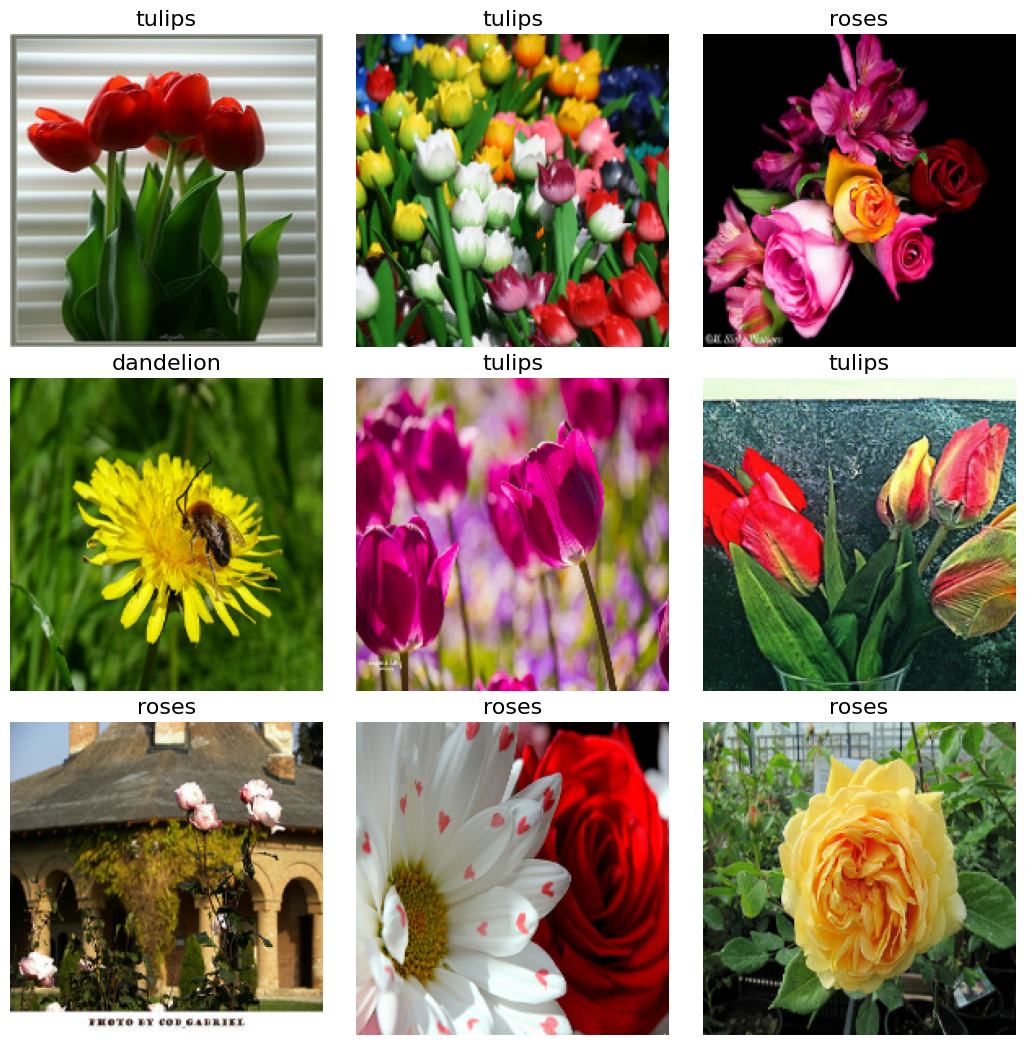

In [12]:
# Displaying images directly from our loaded training dataset
display_9_images_from_dataset(training_dataset.unbatch())

## training and validation datasets

In [17]:
# We have already successfully instantiated, preprocessed, and batched
# our datasets ('training_dataset' and 'validation_dataset') via tensorflow_datasets
# in the cells above. This GCS TFRecord-based loader is kept only as a reference.

def get_batched_dataset(filenames, train=False):
  dataset = load_dataset(filenames)
  dataset = dataset.cache() # This dataset fits in RAM
  if train:
    dataset = dataset.repeat()
  dataset = dataset.batch(BATCH_SIZE)
  dataset = dataset.prefetch(AUTOTUNE)
  return dataset

## Model [WORK REQUIRED]
1. Start with a dummy single-layer model using one dense layer:
 * Use  a [`tf.keras.Sequential`](https://www.tensorflow.org/api_docs/python/tf/keras/models/Sequential) model. The constructor takes a list of layers.
 * First, [`Flatten()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten) the pixel values of the the input image to a 1D vector so that a dense layer can consume it:<br/>
 `tf.keras.layers.Flatten(input_shape=[*IMAGE_SIZE, 3])  # the first layer must also specify input shape`
 * Add a single [`tf.keras.layers.Dense`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) layer with softmax activation and the correct number of units (hint: 5 classes of flowers):<br/>
  `tf.keras.layers.Dense(5, activation='softmax')`
 * add the last bits and pieces with [model.compile()](https://www.tensorflow.org/api_docs/python/tf/keras/models/Model#compile). For a classifier, you need `'sparse_categorical_crossentropy'` loss, `'accuracy'` in metrics and you can use the `'adam'` optimizer.

 **==>Train this model: not very good... but all the plumbing is in place.**

1. Instead of trying to figure out a better architecture, we will adapt a pretrained model to our data. Please remove all your layers to restart from scratch.
 * Instantiate a pre-trained model from `tf.keras.applications.*`
 You do not need its final softmax layer (`include_top=False`) because you will be adding your own. This code is already written in the cell below.<br/>
 * Use `pretrained_model` as your first "layer" in your Sequential model.
 * Follow with  [`tf.keras.layers.Flatten()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten) or [`tf.keras.layers.GlobalAveragePooling2D()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalAveragePooling2D) to turn the data from the pretrained model into a flat 1D vector.
 * Add your [`tf.keras.layers.Dense`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) layer with softmax activation and the correct number of units (hint: 5 classes of flowers).

 **==>Train the model: you should be able to reach above 75% accuracy by training for 10 epochs**

1. You can try adding a second dense layer. Use 'relu' activation on all dense layers but the last one which must be 'softmax'. An additional layer ads trainable weights. It is unlikely to do much good here though, because our dataset is too small.

This technique is called "transfer learning". The pretrained model has been trained on a different dataset but its layers have still learned to recognize bits and pieces of images that can be useful for flowers. You are retraining the last layer only, the pretrained weights are frozen. With far fewer weights to adjust, it works with less data.

In [18]:
pretrained_model = tf.keras.applications.MobileNetV2(input_shape=[*IMAGE_SIZE, 3], include_top=False)
pretrained_model.trainable = False

model = tf.keras.Sequential([
  pretrained_model,
  tf.keras.layers.GlobalAveragePooling2D(),
  tf.keras.layers.Dense(len(CLASSES), activation='softmax')
])

model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_192            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Training

In [19]:
history = model.fit(training_dataset, steps_per_epoch=steps_per_epoch, epochs=EPOCHS,
                    validation_data=validation_dataset)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 50s 559ms/step - accuracy: 0.6828 - loss: 0.8562 - val_accuracy: 0.8364 - val_loss: 0.5137
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8580 - loss: 0.4263 - val_accuracy: 0.8565 - val_loss: 0.4204
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.8893 - loss: 0.3447 - val_accuracy: 0.8780 - val_loss: 0.3807
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9062 - loss: 0.2952 - val_accuracy: 0.8780 - val_loss: 0.3625
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9219 - loss: 0.2533 - val_accuracy: 0.8910 - val_loss: 0.3495


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


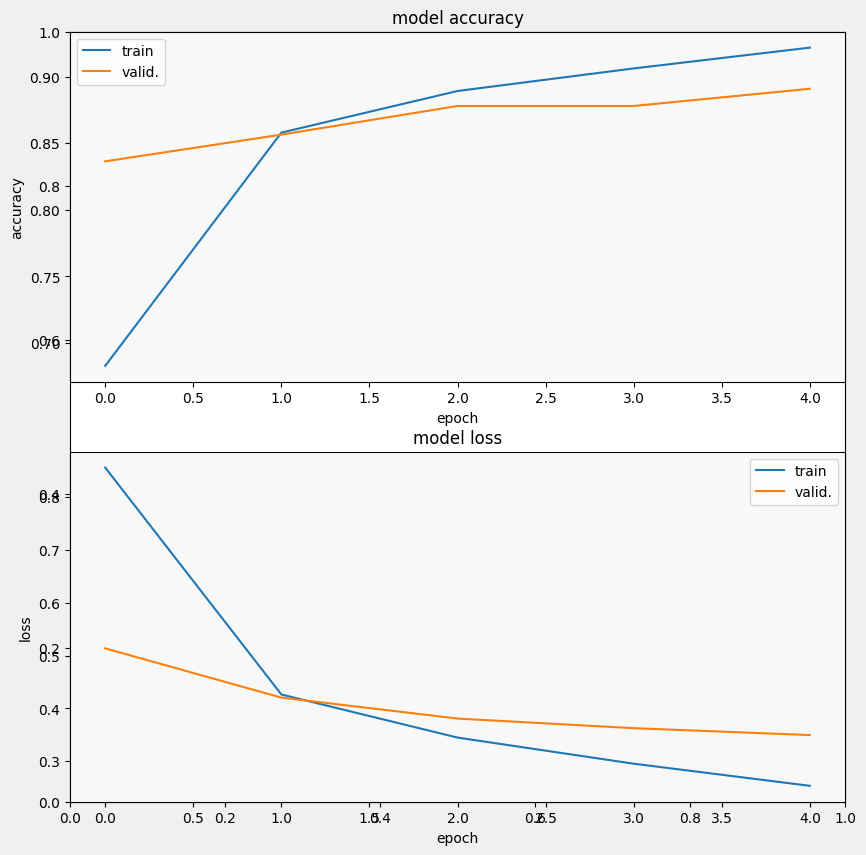

In [20]:
print(history.history.keys())
display_training_curves(history.history['accuracy'], history.history['val_accuracy'], 'accuracy', 211)
display_training_curves(history.history['loss'], history.history['val_loss'], 'loss', 212)

## Predictions

In [21]:
# Retrieve validation images directly from the validation dataset
flowers, labels = dataset_to_numpy_util(validation_dataset.unbatch().skip(np.random.randint(300)), 9)

predictions = model.predict(flowers, steps=1)
print(np.array(CLASSES)[np.argmax(predictions, axis=-1)].tolist())

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
['dandelion', 'sunflowers', 'dandelion', 'roses', 'dandelion', 'sunflowers', 'dandelion', 'roses', 'sunflowers']


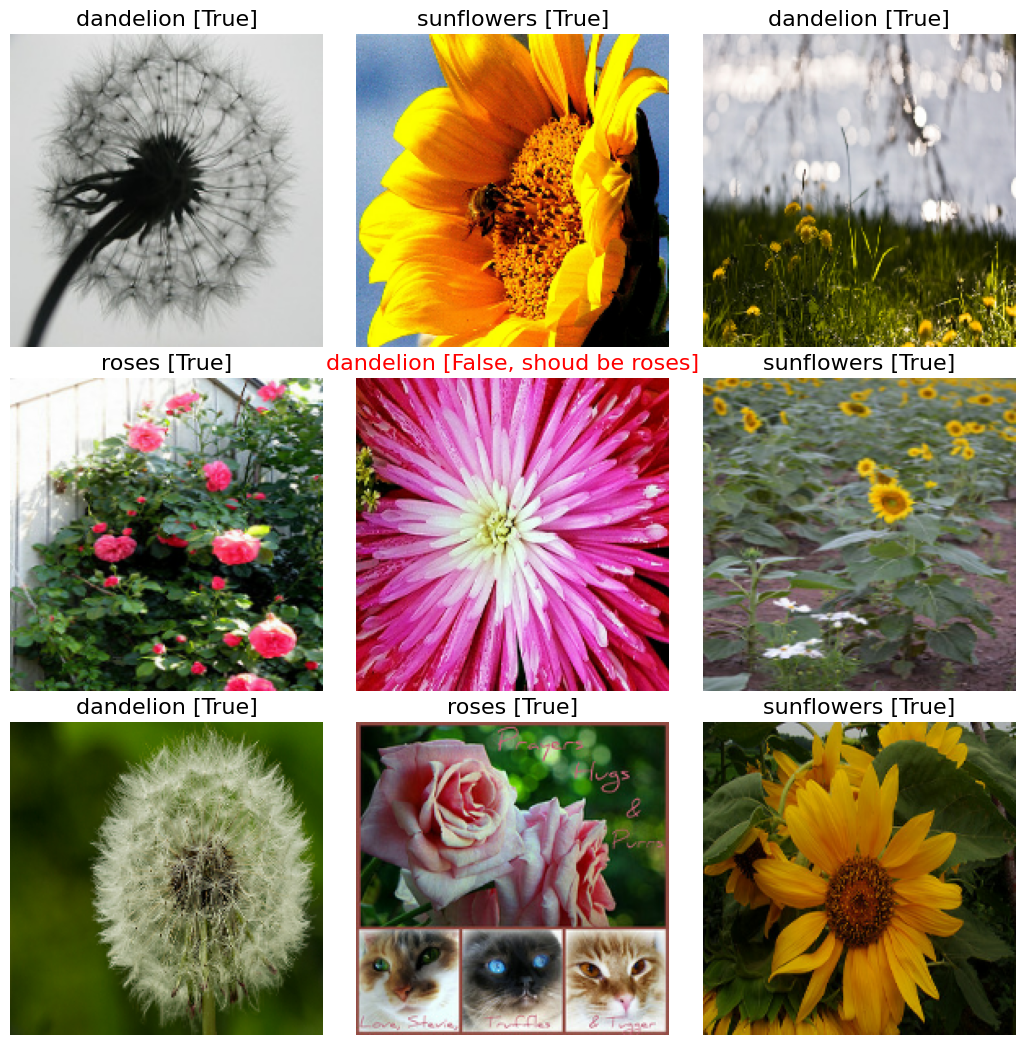

In [22]:
display_9_images_with_predictions(flowers, predictions, labels)